# Chatbot With MCP Server

In [7]:
%pip install langchain-mcp-adapters mcp pywin32 -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [8]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### MCP Server 연동
- `http` 원격지의 MCP Server를 web 방식 호출
- `stdio` MCP Client system에서 MCP Server구동하는 경우

In [9]:
# MultiServerMCPClient로 MCP서버 2개 연결 후 도구 목록 조회
from langchain_mcp_adapters.client import MultiServerMCPClient

CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')

# MCP 서버설정 클라이언트
mcp_client = MultiServerMCPClient({
    # Langchain Docs MCP 서버
    "docs-langchain": {
        "url": "https://docs.langchain.com/mcp",  # 엔드포인트
        "transport": 'http'    # 전송 방식
    },
    # Context7 MCP 서버
    "context7": {
       "url": "https://mcp.context7.com/mcp",    # 엔드포인트
       "headers": {  # 인증정보를 담은 헤더
           "CONTEXT7_API_KEY": CONTEXT7_API_KEY
       },
       "transport": 'http'
    }
})

# get_tools는 비동기 메서드이므로 await로 동작 처리
mcp_tools = await mcp_client.get_tools()  # MCP 서버 Tool 목록 조회
mcp_tools

[StructuredTool(name='search_docs_by_lang_chain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages. If you need the full content of a specific page, use the query_docs_filesystem tool to `head` or `cat` the page path (append `.mdx` to the path returned from search — e.g. `head -200 /api-reference/create-customer.mdx`).', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}}, 'required': ['query'], 'additionalProperties': False}, metadata={'title': None, 'readOnlyHint': True, 'destructiveHint': False, 'idempotentHint': True, 'openWorldHint': False}, handle_tool_error=<function _handle_mcp_tool_

In [10]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool] + mcp_tools
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 파인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

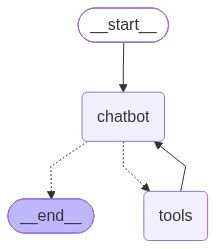

In [11]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

In [12]:
from pprint import pprint

user_query = '최근 삼성전자와 하이닉스 주가는 어떻게 돼?'

state = {'messages': [('human', user_query)]}

response = graph.invoke(state)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 삼성전자와 하이닉스 주가는 어떻게 돼?', additional_kwargs={}, response_metadata={}, id='2c16d5c8-a0eb-4334-b64f-20840f235908'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 3173, 'total_tokens': 3227, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrLDGYe0yERsJs3HQAP2mhZjYBm9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06510-9db3-74d1-83bf-974085678392-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '삼성전자 하이닉스 주가 최근 한국 증시', 'search_depth'

In [15]:
user_query = 'langchain 최신버전에서 새롭게 추가된 부분은? langchain MCP 사용해줘'

state = {'messages': [('human', user_query)]}

response = await graph.ainvoke(state)  # 그래프 비동기 실행
pprint(response)
print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='langchain 최신버전에서 새롭게 추가된 부분은? langchain MCP 사용해줘', additional_kwargs={}, response_metadata={}, id='9c348b00-431a-4dbe-bda1-93a7b8e7c53b'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 3178, 'total_tokens': 3216, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrPDbRxCT9DhOamTRvyLmnrOBsVB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06514-65ec-7463-8468-933780d11d95-0', tool_calls=[{'name': 'resolve-library-id', 'args': {'libraryName': 'Lan

In [18]:
user_query = '웹 프론트엔드 개발시 필요한 패키지 또는 라이브러리가 뭐야? mcp 사용해서 검색해줘'

state = {'messages': [('human', user_query)]}

response = await graph.ainvoke(state)  # 그래프 비동기 실행
pprint(response)
print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='웹 프론트엔드 개발시 필요한 패키지 또는 라이브러리가 뭐야? mcp 사용해서 검색해줘', additional_kwargs={}, response_metadata={}, id='e45c78a2-b168-4402-9e72-d96afb237d91'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 3186, 'total_tokens': 3243, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrSYDWt8wKylr1zr1OyuWU0BqRUT', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06517-8b98-7702-a7ab-45e802065696-0', tool_calls=[{'name': 'resolve-library-id', 'args': {'libraryName': 'Next

In [19]:
from pprint import pprint

user_query = '여름 - 가을로 가는 중간지점에 먹을만한 음식은?'

state = {'messages': [('human', user_query)]}

response = graph.invoke(state)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='여름 - 가을로 가는 중간지점에 먹을만한 음식은?', additional_kwargs={}, response_metadata={}, id='c5f31f60-26e0-4f27-af82-ec2e185419c0'),
              AIMessage(content='여름에서 가을로 넘어가는 **환절기**에는 너무 차갑거나 너무 무거운 음식보다, **수분 보충 + 속을 편하게 해주는 음식**이 잘 맞아요.\n\n추천해볼 만한 음식은:\n\n- **국물 있는 음식**: 미역국, 북엇국, 된장국, 닭곰탕  \n- **제철 채소/과일**: 배, 사과, 포도, 옥수수, 가지, 오이  \n- **가볍지만 든든한 메뉴**: 비빔밥, 죽, 샐러드에 단백질 추가한 것  \n- **환절기 보양식 느낌**: 삼계탕, 장어구이, 버섯전골  \n- **간식/디저트**: 삶은 옥수수, 고구마, 감자, 따뜻한 차\n\n조금 더 실용적으로 말하면:\n- **더위가 남아 있으면**: 냉국, 샐러드, 과일\n- **아침저녁이 선선해지면**: 국, 찌개, 전골\n- **몸이 피곤하면**: 단백질 있는 따뜻한 음식\n\n원하시면 제가  \n1) **한식 위주**,  \n2) **편의점/배달용**,  \n3) **다이어트용**,  \n4) **저렴한 메뉴**  \n중 하나로 더 구체적으로 추천해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 329, 'prompt_tokens': 3179, 'total_tokens': 3508, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': N